# Inventory Risk Backtest

The MM strategy captures spread on round-trips but loses money on unhedged inventory that settles against us.
This notebook replays historical silver data through strategy variants to find parameters that reduce inventory risk.

**Features tested:**
1. Scaled per-ticker skew (widen proportional to position size)
2. Position age-based skew (widen as position ages)
3. Absolute exposure soft limit (stop opening new positions when total exposure is high)
4. Player-level correlated skew (track net position across thresholds for same player)

In [19]:
import io
import re
import sys
from dataclasses import dataclass, field
from datetime import date, timedelta
from typing import Any

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

sys.path.insert(0, '../..')
from app.events import (
    BookInvalidated, Event, MMFillEvent, MMQuoteEvent,
    OrderBookUpdate, TradeEvent,
)
from app.strategy.mm import maker_fee_cents, OrderSideState

s3 = boto3.client('s3')
BUCKET = 'prediction-markets-data'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load silver data

In [20]:
def load_silver(event_type: str, dates: list[date]) -> pd.DataFrame:
    frames = []
    for d in dates:
        prefix = f'silver/kalshi_ws/{event_type}/date={d}/'
        pages = s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix)
        keys = [o['Key'] for page in pages for o in page.get('Contents', [])]
        for k in keys:
            raw = s3.get_object(Bucket=BUCKET, Key=k)['Body'].read()
            frames.append(pd.read_parquet(io.BytesIO(raw)))
        if keys:
            print(f'  {event_type} {d}: {len(keys)} files')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

# Load 7 days of data
today = date(2026, 4, 25)
dates = [today - timedelta(days=i) for i in range(7)]

print('Loading OrderBookUpdate...')
book_df = load_silver('OrderBookUpdate', dates)
print(f'\nLoading TradeEvent...')
trade_df = load_silver('TradeEvent', dates)

# Filter to KXNBAPTS only
book_df = book_df[book_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()
trade_df = trade_df[trade_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()

print(f'\nKXNBAPTS data:')
print(f'  OrderBookUpdate: {len(book_df):,} rows, {book_df["market_ticker"].nunique()} tickers')
print(f'  TradeEvent:      {len(trade_df):,} rows, {trade_df["market_ticker"].nunique()} tickers')
print(f'  Date range:      {book_df["t_receipt"].min():.0f} to {book_df["t_receipt"].max():.0f}')

Loading OrderBookUpdate...
  OrderBookUpdate 2026-04-25: 960 files

Loading TradeEvent...
  TradeEvent 2026-04-25: 950 files

KXNBAPTS data:
  OrderBookUpdate: 950,522 rows, 296 tickers
  TradeEvent:      8,952 rows, 213 tickers
  Date range:      1777083847 to 1777143891


## 2. Build event stream

In [21]:
# Convert DataFrames to sorted Event objects for replay
events: list[Event] = []

for _, row in book_df.iterrows():
    events.append(OrderBookUpdate(
        t_receipt=row['t_receipt'],
        market_ticker=row['market_ticker'],
        bid_yes=int(row['bid_yes']),
        ask_yes=int(row['ask_yes']),
        bid_size=int(row.get('bid_size', 10000)),
        ask_size=int(row.get('ask_size', 10000)),
    ))

for _, row in trade_df.iterrows():
    events.append(TradeEvent(
        t_receipt=row['t_receipt'],
        market_ticker=row['market_ticker'],
        side=row['side'],
        price=int(row['price']),
        size=int(row['size']),
    ))

events.sort(key=lambda e: e.t_receipt)
print(f'Total events: {len(events):,}')
print(f'  OrderBookUpdate: {sum(1 for e in events if isinstance(e, OrderBookUpdate)):,}')
print(f'  TradeEvent:      {sum(1 for e in events if isinstance(e, TradeEvent)):,}')

Total events: 959,474
  OrderBookUpdate: 950,522
  TradeEvent:      8,952


## 3. Look up settlements

In [22]:
# Get all unique KXNBAPTS tickers in the trade data
all_tickers = sorted(trade_df['market_ticker'].unique())
print(f'Looking up settlements for {len(all_tickers)} tickers...')

settlements: dict[str, str | None] = {}
for i, ticker in enumerate(all_tickers, 1):
    if i % 50 == 0 or i == len(all_tickers):
        print(f'  {i}/{len(all_tickers)}', end='\r')
    try:
        resp = requests.get(
            f'https://api.elections.kalshi.com/trade-api/v2/markets/{ticker}',
            timeout=10,
        )
        resp.raise_for_status()
        result = resp.json().get('market', {}).get('result')
        settlements[ticker] = result if result in ('yes', 'no') else None
    except Exception:
        settlements[ticker] = None

n_yes = sum(1 for v in settlements.values() if v == 'yes')
n_no = sum(1 for v in settlements.values() if v == 'no')
n_unk = sum(1 for v in settlements.values() if v is None)
print(f'\nSettlements: {n_yes} YES, {n_no} NO, {n_unk} unsettled')

Looking up settlements for 213 tickers...
  213/213
Settlements: 17 YES, 20 NO, 176 unsettled


## 4. Enhanced strategy (backtest variant)

Self-contained strategy with all 4 inventory risk features as config flags.
Mirrors production `MMStrategy` + `PaperOrderClient` exactly, with additions.

In [23]:
@dataclass
class BTConfig:
    """Backtest config — production defaults + new inventory risk params."""
    # --- existing production params ---
    min_spread_cents: int = 3
    min_edge_cents: int = 1
    max_position: int = 10
    max_aggregate_position: int = 200
    order_size: int = 1
    series_filter: str = 'KXNBAPTS-'
    # existing per-ticker skew
    skew_threshold: int = 3
    # existing aggregate skew
    agg_skew_threshold: int = 5
    agg_skew_max: int = 15
    agg_skew_step_size: int = 5
    agg_skew_step_cents: int = 1
    
    # --- NEW: scaled per-ticker skew ---
    skew_cents_per_contract: int = 0  # 0 = use old fixed-1c logic
    
    # --- NEW: position age skew ---
    age_skew_interval_s: float = 0.0  # 0 = disabled
    age_skew_step_cents: int = 1
    max_age_skew_cents: int = 10
    
    # --- NEW: absolute exposure soft limit ---
    abs_exposure_soft_limit: int = 0  # 0 = disabled
    
    # --- NEW: player-level skew ---
    use_player_skew: bool = False
    player_skew_cents_per_contract: int = 1
    
    # --- NEW: minimum volume filter ---
    min_trades_to_quote: int = 0  # 0 = disabled; skip tickers with fewer observed trades


class BTPaperClient:
    """Minimal PaperOrderClient for backtest replay."""

    def __init__(self, strategy: 'BTStrategy') -> None:
        self._strategy = strategy
        self._resting: dict[str, dict] = {}
        self._next_id: int = 0

    def place_limit(self, ticker, side, price_cents, size, t):
        oid = f'bt-{self._next_id}'
        self._next_id += 1
        self._resting[oid] = {'ticker': ticker, 'side': side, 'price': price_cents, 'remaining': size}
        self._strategy.on_order_ack(ticker, side, oid)
        return oid

    def cancel(self, ticker, side, order_id, t):
        self._resting.pop(order_id, None)
        self._strategy.on_cancel_ack(ticker, side)

    def check_fill(self, trade: TradeEvent):
        for oid in list(self._resting):
            info = self._resting.get(oid)
            if info is None or info['ticker'] != trade.market_ticker:
                continue
            if info['side'] == 'bid' and trade.side == 'no' and trade.price == info['price']:
                fs = min(info['remaining'], trade.size)
                info['remaining'] -= fs
                if info['remaining'] <= 0:
                    del self._resting[oid]
                self._strategy.on_fill(
                    info['ticker'], 'bid', fs,
                    info['remaining'] if oid in self._resting else 0,
                    info['price'], oid, trade.t_receipt)
                return
            if info['side'] == 'ask' and trade.side == 'yes' and trade.price == info['price']:
                fs = min(info['remaining'], trade.size)
                info['remaining'] -= fs
                if info['remaining'] <= 0:
                    del self._resting[oid]
                self._strategy.on_fill(
                    info['ticker'], 'ask', fs,
                    info['remaining'] if oid in self._resting else 0,
                    info['price'], oid, trade.t_receipt)
                return


class BTStrategy:
    """MMStrategy with inventory risk features for backtesting."""

    def __init__(self, config: BTConfig | None = None) -> None:
        self._config = config or BTConfig()
        self._client: BTPaperClient | None = None
        self._positions: dict[str, int] = {}
        self._aggregate_abs_position: int = 0
        self._agg_net_position: int = 0
        self._order_state: dict[str, dict[str, OrderSideState]] = {}
        self._last_quote: dict[str, tuple[int | None, int | None]] = {}
        self.fills: list[dict] = []
        # NEW: position age tracking
        self._position_opened_at: dict[str, float] = {}
        # NEW: player-level positions
        self._player_positions: dict[str, int] = {}
        # NEW: trade count per ticker (for volume filter)
        self._trade_counts: dict[str, int] = {}

    def set_client(self, client: BTPaperClient):
        self._client = client

    @staticmethod
    def _player_key(ticker: str) -> str | None:
        parts = ticker.split('-')
        return parts[2] if len(parts) >= 4 else None

    def _get_side(self, ticker, side) -> OrderSideState:
        if ticker not in self._order_state:
            self._order_state[ticker] = {'bid': OrderSideState(), 'ask': OrderSideState()}
        return self._order_state[ticker][side]

    def on_event(self, event: Event) -> None:
        if isinstance(event, OrderBookUpdate):
            self._on_book_update(event)
        elif isinstance(event, TradeEvent):
            self._on_trade(event)
        elif isinstance(event, BookInvalidated):
            self._on_book_invalidated(event)

    def on_order_ack(self, ticker, side, order_id):
        state = self._get_side(ticker, side)
        if state.state == 'pending':
            state.state = 'resting'
            state.order_id = order_id

    def on_cancel_ack(self, ticker, side):
        state = self._get_side(ticker, side)
        state.state = 'idle'
        state.order_id = None
        state.price = None

    def on_fill(self, ticker, side, fill_size, remaining_size, price, order_id, t):
        pos_before = self._positions.get(ticker, 0)
        delta = fill_size if side == 'bid' else -fill_size
        pos_after = pos_before + delta
        self._positions[ticker] = pos_after
        self._aggregate_abs_position = sum(abs(v) for v in self._positions.values())
        self._agg_net_position = sum(self._positions.values())

        # Position age tracking
        if pos_before == 0 and pos_after != 0:
            self._position_opened_at[ticker] = t
        elif pos_after == 0:
            self._position_opened_at.pop(ticker, None)

        # Player position tracking
        pk = self._player_key(ticker)
        if pk:
            self._player_positions[pk] = self._player_positions.get(pk, 0) + delta

        state = self._get_side(ticker, side)
        state.remaining_size = remaining_size
        if remaining_size == 0:
            state.state = 'idle'
            state.order_id = None
            state.price = None

        self.fills.append({
            't_receipt': t,
            'market_ticker': ticker,
            'side': 'buy' if side == 'bid' else 'sell',
            'price': price,
            'fill_size': fill_size,
            'position_before': pos_before,
            'position_after': pos_after,
            'maker_fee': maker_fee_cents(price),
        })

    def _agg_skew_adjustment(self):
        net = self._agg_net_position
        cfg = self._config
        bid_adj, ask_adj = 0, 0
        suppress_bid, suppress_ask = False, False
        if net <= -cfg.agg_skew_max:
            suppress_ask = True
        elif net <= -cfg.agg_skew_threshold:
            steps = (-net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            ask_adj = steps * cfg.agg_skew_step_cents
        if net >= cfg.agg_skew_max:
            suppress_bid = True
        elif net >= cfg.agg_skew_threshold:
            steps = (net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            bid_adj = steps * cfg.agg_skew_step_cents
        return bid_adj, ask_adj, suppress_bid, suppress_ask

    def _on_book_update(self, update: OrderBookUpdate):
        ticker = update.market_ticker
        if not ticker.startswith(self._config.series_filter):
            return
        spread = update.ask_yes - update.bid_yes
        if spread <= 0:
            return
        position = self._positions.get(ticker, 0)
        mid = (update.bid_yes + update.ask_yes) // 2
        fee = maker_fee_cents(mid)
        net_half_spread = (spread // 2) - fee

        reason_no_bid: str | None = None
        reason_no_ask: str | None = None

        if net_half_spread < self._config.min_edge_cents:
            reason_no_bid = 'spread_narrow'
            reason_no_ask = 'spread_narrow'
        if position >= self._config.max_position:
            reason_no_bid = 'pos_limit'
        if position <= -self._config.max_position:
            reason_no_ask = 'pos_limit'
        if self._aggregate_abs_position >= self._config.max_aggregate_position:
            if reason_no_bid is None:
                reason_no_bid = 'agg_limit'
            if reason_no_ask is None:
                reason_no_ask = 'agg_limit'

        # --- NEW: minimum volume filter ---
        if self._config.min_trades_to_quote > 0:
            if self._trade_counts.get(ticker, 0) < self._config.min_trades_to_quote:
                if reason_no_bid is None:
                    reason_no_bid = 'low_volume'
                if reason_no_ask is None:
                    reason_no_ask = 'low_volume'

        # --- NEW: absolute exposure soft limit ---
        if (self._config.abs_exposure_soft_limit > 0
                and self._aggregate_abs_position >= self._config.abs_exposure_soft_limit):
            # Only allow orders that reduce abs exposure
            if position >= 0 and reason_no_bid is None:
                reason_no_bid = 'abs_soft_limit'
            if position <= 0 and reason_no_ask is None:
                reason_no_ask = 'abs_soft_limit'

        # Skew quotes when carrying inventory
        bid_price = update.bid_yes
        ask_price = update.ask_yes

        # --- Per-ticker skew (original or scaled) ---
        if self._config.skew_cents_per_contract > 0:
            # NEW: scaled skew
            if abs(position) >= self._config.skew_threshold:
                skew = abs(position) * self._config.skew_cents_per_contract
                if position > 0:
                    bid_price = max(1, bid_price - skew)
                else:
                    ask_price = min(99, ask_price + skew)
        else:
            # Original fixed 1c skew
            if position > self._config.skew_threshold:
                bid_price = max(1, bid_price - 1)
            elif position < -self._config.skew_threshold:
                ask_price = min(99, ask_price + 1)

        # --- NEW: position age skew ---
        if self._config.age_skew_interval_s > 0 and position != 0:
            opened_at = self._position_opened_at.get(ticker)
            if opened_at is not None:
                age_s = update.t_receipt - opened_at
                age_tiers = int(age_s / self._config.age_skew_interval_s)
                age_skew = min(age_tiers * self._config.age_skew_step_cents,
                               self._config.max_age_skew_cents)
                if age_skew > 0:
                    if position > 0:
                        bid_price = max(1, bid_price - age_skew)
                    else:
                        ask_price = min(99, ask_price + age_skew)

        # --- NEW: player-level skew ---
        if self._config.use_player_skew:
            pk = self._player_key(ticker)
            if pk:
                player_pos = self._player_positions.get(pk, 0)
                if player_pos != 0:
                    p_skew = abs(player_pos) * self._config.player_skew_cents_per_contract
                    if player_pos > 0:
                        bid_price = max(1, bid_price - p_skew)
                    else:
                        ask_price = min(99, ask_price + p_skew)

        # Aggregate directional skew (existing)
        bid_adj, ask_adj, suppress_bid, suppress_ask = self._agg_skew_adjustment()
        if suppress_bid:
            reason_no_bid = reason_no_bid or 'agg_skew'
        elif bid_adj > 0:
            bid_price = max(1, bid_price - bid_adj)
        if suppress_ask:
            reason_no_ask = reason_no_ask or 'agg_skew'
        elif ask_adj > 0:
            ask_price = min(99, ask_price + ask_adj)

        should_bid = reason_no_bid is None
        should_ask = reason_no_ask is None
        desired_bid = bid_price if should_bid else None
        desired_ask = ask_price if should_ask else None

        last = self._last_quote.get(ticker)
        if last != (desired_bid, desired_ask):
            self._last_quote[ticker] = (desired_bid, desired_ask)

        self._maybe_update_side(ticker, 'bid', desired_bid, update.t_receipt)
        self._maybe_update_side(ticker, 'ask', desired_ask, update.t_receipt)

    def _on_trade(self, trade: TradeEvent):
        if not trade.market_ticker.startswith(self._config.series_filter):
            return
        # Track trade counts for volume filter
        self._trade_counts[trade.market_ticker] = self._trade_counts.get(trade.market_ticker, 0) + 1
        self._client.check_fill(trade)

    def _on_book_invalidated(self, event: BookInvalidated):
        ticker = event.market_ticker
        for side in ('bid', 'ask'):
            state = self._get_side(ticker, side)
            if state.state == 'resting':
                self._client.cancel(ticker, side, state.order_id or '', event.t_receipt)
            elif state.state == 'pending':
                state.state = 'idle'
                state.order_id = None
                state.price = None
        self._last_quote.pop(ticker, None)

    def _maybe_update_side(self, ticker, side, price, t):
        state = self._get_side(ticker, side)
        if price is None:
            if state.state == 'resting':
                state.state = 'cancel_pending'
                self._client.cancel(ticker, side, state.order_id or '', t)
            return
        if state.state == 'idle':
            state.state = 'pending'
            state.price = price
            state.remaining_size = self._config.order_size
            self._client.place_limit(ticker, side, price, self._config.order_size, t)
        elif state.state == 'resting' and state.price != price:
            state.state = 'cancel_pending'
            self._client.cancel(ticker, side, state.order_id or '', t)

## 5. Backtest engine

In [24]:
def run_backtest(config: BTConfig, events: list[Event], settlements: dict) -> dict:
    """Replay events through strategy and compute full P&L."""
    strategy = BTStrategy(config)
    client = BTPaperClient(strategy)
    strategy.set_client(client)

    for event in events:
        strategy.on_event(event)

    if not strategy.fills:
        return {'name': '', 'fills': 0, 'round_trips': 0, 'realized_pnl': 0,
                'settled_pnl': 0, 'total_pnl': 0, 'win_rate': 0,
                'open_positions': 0, 'max_abs_exposure': 0, 'max_net_exposure': 0,
                'settled_wins': 0, 'settled_losses': 0}

    fills = pd.DataFrame(strategy.fills)

    # --- Round-trip P&L ---
    realized = 0
    rt_count = 0
    rt_wins = 0
    for ticker, g in fills.groupby('market_ticker'):
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        for i in range(pairs):
            b, s = buys.iloc[i], sells.iloc[i]
            pnl = s['price'] - b['price'] - b['maker_fee'] - s['maker_fee']
            realized += pnl
            rt_count += 1
            if pnl > 0:
                rt_wins += 1

    # --- Open position P&L via settlements ---
    settled_pnl = 0
    settled_wins = 0
    settled_losses = 0
    open_count = 0
    for ticker, g in fills.groupby('market_ticker'):
        pos = g['position_after'].iloc[-1]
        if pos == 0:
            continue
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))

        if pos > 0:
            unpaired = buys.iloc[pairs:]
        else:
            unpaired = sells.iloc[pairs:]

        settlement = settlements.get(ticker)
        if settlement is None:
            open_count += abs(pos)
            continue

        for _, fill in unpaired.iterrows():
            if pos > 0:  # long YES
                if settlement == 'yes':
                    p = (100 - fill['price']) - fill['maker_fee']
                else:
                    p = -(fill['price'] + fill['maker_fee'])
            else:  # short YES
                if settlement == 'no':
                    p = fill['price'] - fill['maker_fee']
                else:
                    p = -(100 - fill['price'] + fill['maker_fee'])
            settled_pnl += p
            if p > 0:
                settled_wins += 1
            else:
                settled_losses += 1

    # --- Exposure tracking ---
    # Replay positions to find max exposure
    positions: dict[str, int] = {}
    max_abs = 0
    max_net = 0
    for _, f in fills.iterrows():
        positions[f['market_ticker']] = f['position_after']
        abs_exp = sum(abs(v) for v in positions.values())
        net_exp = abs(sum(positions.values()))
        max_abs = max(max_abs, abs_exp)
        max_net = max(max_net, net_exp)

    return {
        'fills': len(fills),
        'round_trips': rt_count,
        'realized_pnl': realized,
        'win_rate': rt_wins / rt_count if rt_count > 0 else 0,
        'settled_pnl': settled_pnl,
        'total_pnl': realized + settled_pnl,
        'open_positions': open_count,
        'max_abs_exposure': max_abs,
        'max_net_exposure': max_net,
        'settled_wins': settled_wins,
        'settled_losses': settled_losses,
    }

## 6. Baseline

In [25]:
baseline_config = BTConfig()  # all production defaults
baseline = run_backtest(baseline_config, events, settlements)
baseline['name'] = 'baseline'

def print_result(r):
    print(f"  Fills:           {r['fills']}")
    print(f"  Round-trips:     {r['round_trips']}  (win rate: {r['win_rate']:.0%})")
    print(f"  Realized P&L:    {r['realized_pnl']:+.0f}c (${r['realized_pnl']/100:+.2f})")
    print(f"  Settled open:    {r['settled_pnl']:+.0f}c (${r['settled_pnl']/100:+.2f})  "
          f"[{r['settled_wins']}W / {r['settled_losses']}L]")
    print(f"  Total P&L:       {r['total_pnl']:+.0f}c (${r['total_pnl']/100:+.2f})")
    print(f"  Open (unsettled):{r['open_positions']} contracts")
    print(f"  Max abs exposure:{r['max_abs_exposure']}  Max net: {r['max_net_exposure']}")

print('=== BASELINE ===')
print_result(baseline)

=== BASELINE ===
  Fills:           272
  Round-trips:     65  (win rate: 72%)
  Realized P&L:    +430c ($+4.30)
  Settled open:    -83c ($-0.83)  [7W / 42L]
  Total P&L:       +347c ($+3.47)
  Open (unsettled):93 contracts
  Max abs exposure:143  Max net: 26


## 7. Sweep: Scaled per-ticker skew

Test `skew_threshold` x `skew_cents_per_contract` grid.

In [26]:
skew_results = []
for thresh in [1, 2, 3]:
    for cpc in [1, 2, 3, 4]:
        cfg = BTConfig(skew_threshold=thresh, skew_cents_per_contract=cpc)
        r = run_backtest(cfg, events, settlements)
        r['name'] = f'skew_t{thresh}_c{cpc}'
        r['skew_threshold'] = thresh
        r['skew_cents_per_contract'] = cpc
        skew_results.append(r)
        print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
              f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
              f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

skew_df = pd.DataFrame(skew_results)
best_skew = skew_df.loc[skew_df['total_pnl'].idxmax()]
print(f"\nBest: {best_skew['name']} → {best_skew['total_pnl']:+.0f}c")

skew_t1_c1            total=  -61c  realized= +285c  settled= -346c  fills=194  max_abs=91
skew_t1_c2            total=  -77c  realized= +271c  settled= -348c  fills=187  max_abs=92
skew_t1_c3            total=  -88c  realized= +271c  settled= -359c  fills=188  max_abs=92
skew_t1_c4            total=  -76c  realized= +271c  settled= -347c  fills=187  max_abs=92
skew_t2_c1            total= +104c  realized= +341c  settled= -237c  fills=224  max_abs=110
skew_t2_c2            total= +105c  realized= +341c  settled= -236c  fills=224  max_abs=110
skew_t2_c3            total= +105c  realized= +341c  settled= -236c  fills=224  max_abs=110
skew_t2_c4            total= +105c  realized= +341c  settled= -236c  fills=224  max_abs=110
skew_t3_c1            total= +177c  realized= +438c  settled= -261c  fills=258  max_abs=131
skew_t3_c2            total= +177c  realized= +438c  settled= -261c  fills=258  max_abs=131
skew_t3_c3            total= +177c  realized= +438c  settled= -261c  fills=258  max_

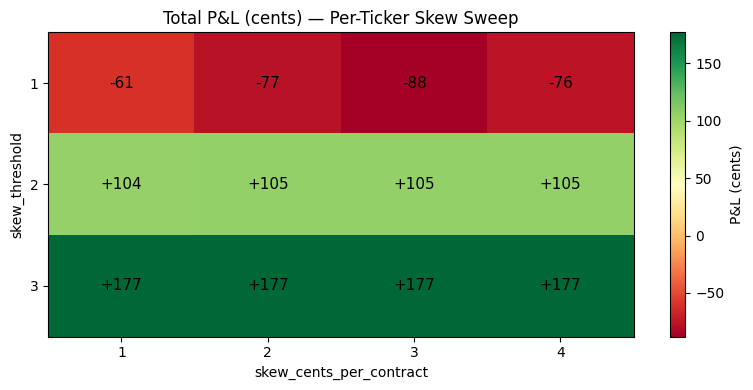

In [27]:
# Heatmap: skew_threshold x skew_cents_per_contract → total P&L
pivot = skew_df.pivot(index='skew_threshold', columns='skew_cents_per_contract', values='total_pnl')
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('skew_cents_per_contract')
ax.set_ylabel('skew_threshold')
ax.set_title('Total P&L (cents) — Per-Ticker Skew Sweep')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:+.0f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='P&L (cents)')
plt.tight_layout()
plt.show()

## 8. Sweep: Position age skew

Test `age_skew_interval_s` x `age_skew_step_cents` grid.

In [28]:
age_results = []
for interval in [300, 600, 900, 1800]:
    for step in [1, 2, 3]:
        cfg = BTConfig(age_skew_interval_s=interval, age_skew_step_cents=step)
        r = run_backtest(cfg, events, settlements)
        r['name'] = f'age_{interval}s_{step}c'
        r['interval'] = interval
        r['step'] = step
        age_results.append(r)
        print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
              f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
              f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

age_df = pd.DataFrame(age_results)
best_age = age_df.loc[age_df['total_pnl'].idxmax()]
print(f"\nBest: {best_age['name']} → {best_age['total_pnl']:+.0f}c")

age_300s_1c           total=  -77c  realized= +298c  settled= -375c  fills=207  max_abs=103
age_300s_2c           total=  -82c  realized= +293c  settled= -375c  fills=205  max_abs=102
age_300s_3c           total=  -94c  realized= +293c  settled= -387c  fills=206  max_abs=102
age_600s_1c           total=  +84c  realized= +459c  settled= -375c  fills=212  max_abs=103
age_600s_2c           total= +119c  realized= +411c  settled= -292c  fills=214  max_abs=103
age_600s_3c           total= +119c  realized= +411c  settled= -292c  fills=214  max_abs=103
age_900s_1c           total= +223c  realized= +549c  settled= -326c  fills=225  max_abs=107
age_900s_2c           total= +220c  realized= +549c  settled= -329c  fills=227  max_abs=109
age_900s_3c           total= +255c  realized= +583c  settled= -328c  fills=229  max_abs=109
age_1800s_1c          total= +322c  realized= +618c  settled= -296c  fills=255  max_abs=123
age_1800s_2c          total= +322c  realized= +618c  settled= -296c  fills=255  

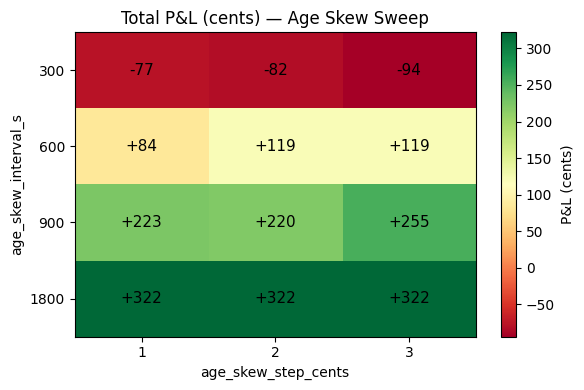

In [29]:
pivot = age_df.pivot(index='interval', columns='step', values='total_pnl')
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('age_skew_step_cents')
ax.set_ylabel('age_skew_interval_s')
ax.set_title('Total P&L (cents) — Age Skew Sweep')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:+.0f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='P&L (cents)')
plt.tight_layout()
plt.show()

## 9. Sweep: Absolute exposure soft limit

abs_limit_20          total=  -21c  realized=  +78c  settled=  -99c  fills=47  max_abs=31
abs_limit_30          total=  +25c  realized= +144c  settled= -119c  fills=68  max_abs=31
abs_limit_40          total=  -62c  realized= +336c  settled= -398c  fills=106  max_abs=41
abs_limit_50          total= +232c  realized= +321c  settled=  -89c  fills=126  max_abs=51
abs_limit_75          total= +149c  realized= +228c  settled=  -79c  fills=154  max_abs=75
abs_limit_100         total= +342c  realized= +425c  settled=  -83c  fills=255  max_abs=101
abs_limit_150         total= +347c  realized= +430c  settled=  -83c  fills=272  max_abs=143

Best: abs_limit_150 → +347c


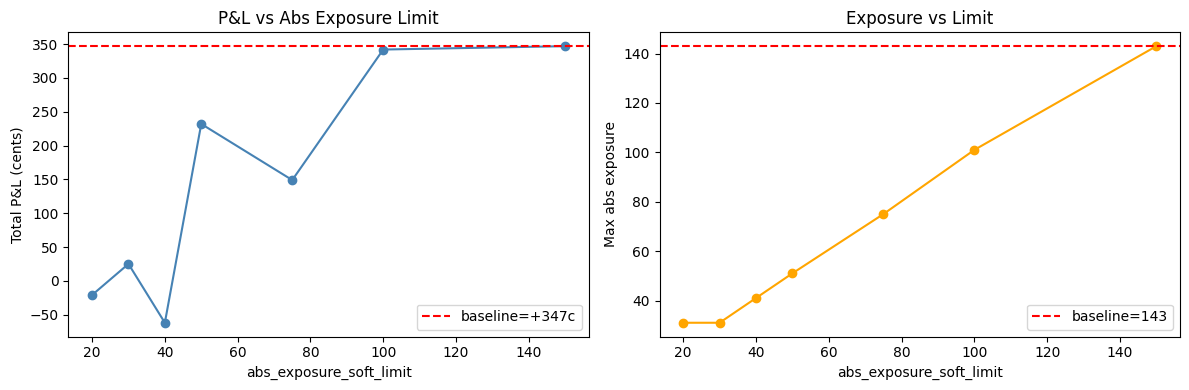

In [30]:
abs_results = []
for limit in [20, 30, 40, 50, 75, 100, 150]:
    cfg = BTConfig(abs_exposure_soft_limit=limit)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'abs_limit_{limit}'
    r['limit'] = limit
    abs_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

abs_df = pd.DataFrame(abs_results)
best_abs = abs_df.loc[abs_df['total_pnl'].idxmax()]
print(f"\nBest: {best_abs['name']} → {best_abs['total_pnl']:+.0f}c")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(abs_df['limit'], abs_df['total_pnl'], 'o-', color='steelblue')
ax.axhline(baseline['total_pnl'], color='red', linestyle='--', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('abs_exposure_soft_limit')
ax.set_ylabel('Total P&L (cents)')
ax.set_title('P&L vs Abs Exposure Limit')
ax.legend()

ax = axes[1]
ax.plot(abs_df['limit'], abs_df['max_abs_exposure'], 'o-', color='orange')
ax.axhline(baseline['max_abs_exposure'], color='red', linestyle='--', label=f"baseline={baseline['max_abs_exposure']}")
ax.set_xlabel('abs_exposure_soft_limit')
ax.set_ylabel('Max abs exposure')
ax.set_title('Exposure vs Limit')
ax.legend()

plt.tight_layout()
plt.show()

## 10. Sweep: Player-level skew

In [31]:
player_results = []
for cpc in [1, 2, 3, 4]:
    cfg = BTConfig(use_player_skew=True, player_skew_cents_per_contract=cpc)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'player_skew_{cpc}c'
    r['player_cpc'] = cpc
    player_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

player_df = pd.DataFrame(player_results)
best_player = player_df.loc[player_df['total_pnl'].idxmax()]
print(f"\nBest: {best_player['name']} → {best_player['total_pnl']:+.0f}c")

player_skew_1c        total= +205c  realized= +494c  settled= -289c  fills=200  max_abs=97
player_skew_2c        total= +206c  realized= +495c  settled= -289c  fills=200  max_abs=98
player_skew_3c        total= +193c  realized= +484c  settled= -291c  fills=201  max_abs=97
player_skew_4c        total= +205c  realized= +494c  settled= -289c  fills=200  max_abs=97

Best: player_skew_2c → +206c


## 10b. Sweep: Minimum volume filter

Only quote on tickers that have seen at least N trades. This avoids illiquid markets
where we get filled on one side and never get offsetting flow.

min_vol_0             total= +347c  realized= +430c  settled=  -83c  fills=272  max_abs=143
min_vol_2             total= +130c  realized= +472c  settled= -342c  fills=256  max_abs=125
min_vol_3             total= +192c  realized= +488c  settled= -296c  fills=250  max_abs=113
min_vol_5             total= +256c  realized= +521c  settled= -265c  fills=245  max_abs=107
min_vol_8             total= +221c  realized= +488c  settled= -267c  fills=231  max_abs=99
min_vol_10            total= +200c  realized= +460c  settled= -260c  fills=225  max_abs=97
min_vol_15            total= +228c  realized= +425c  settled= -197c  fills=216  max_abs=85
min_vol_20            total= +354c  realized= +478c  settled= -124c  fills=216  max_abs=85

Best: min_vol_20 -> +354c


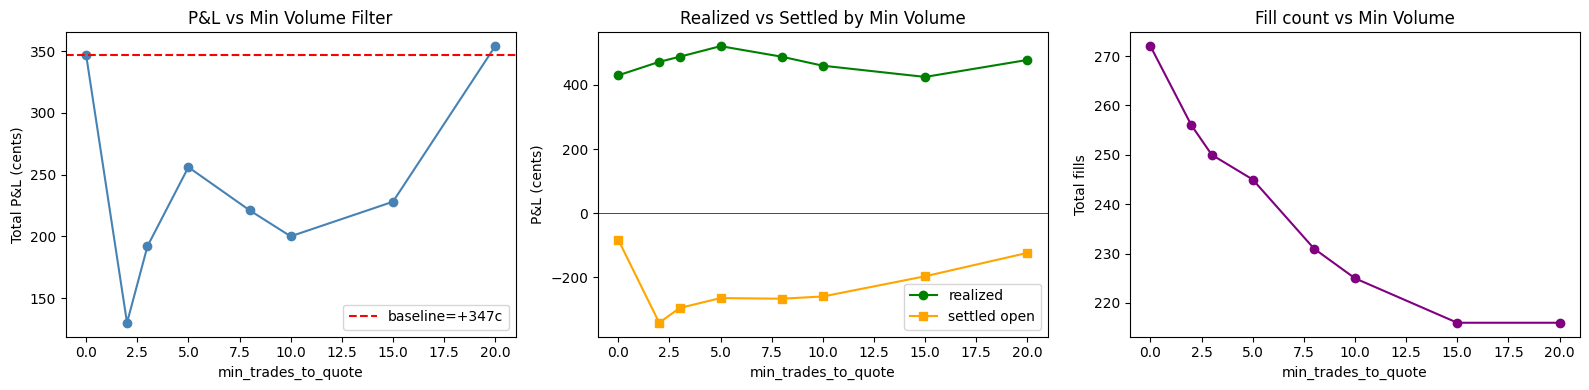

In [32]:
vol_results = []
for min_trades in [0, 2, 3, 5, 8, 10, 15, 20]:
    cfg = BTConfig(min_trades_to_quote=min_trades)
    r = run_backtest(cfg, events, settlements)
    r['name'] = f'min_vol_{min_trades}'
    r['min_trades'] = min_trades
    vol_results.append(r)
    print(f"{r['name']:20s}  total={r['total_pnl']:+5.0f}c  "
          f"realized={r['realized_pnl']:+5.0f}c  settled={r['settled_pnl']:+5.0f}c  "
          f"fills={r['fills']}  max_abs={r['max_abs_exposure']}")

vol_df = pd.DataFrame(vol_results)
best_vol = vol_df.loc[vol_df['total_pnl'].idxmax()]
print(f"\nBest: {best_vol['name']} -> {best_vol['total_pnl']:+.0f}c")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(vol_df['min_trades'], vol_df['total_pnl'], 'o-', color='steelblue')
ax.axhline(baseline['total_pnl'], color='red', linestyle='--', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('Total P&L (cents)')
ax.set_title('P&L vs Min Volume Filter')
ax.legend()

ax = axes[1]
ax.plot(vol_df['min_trades'], vol_df['realized_pnl'], 'o-', color='green', label='realized')
ax.plot(vol_df['min_trades'], vol_df['settled_pnl'], 's-', color='orange', label='settled open')
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('P&L (cents)')
ax.set_title('Realized vs Settled by Min Volume')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[2]
ax.plot(vol_df['min_trades'], vol_df['fills'], 'o-', color='purple')
ax.set_xlabel('min_trades_to_quote')
ax.set_ylabel('Total fills')
ax.set_title('Fill count vs Min Volume')

plt.tight_layout()
plt.show()

## 11. Combined: best params from each sweep

In [33]:
# Build combined config from best individual params
combined_configs = [
    ('baseline', BTConfig()),
    ('best_skew_only', BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
    )),
    ('best_age_only', BTConfig(
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
    )),
    ('best_abs_only', BTConfig(
        abs_exposure_soft_limit=int(best_abs['limit']),
    )),
    ('best_player_only', BTConfig(
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
    )),
    ('best_vol_only', BTConfig(
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
    ('abs+vol', BTConfig(
        abs_exposure_soft_limit=int(best_abs['limit']),
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
    ('all_combined', BTConfig(
        skew_threshold=int(best_skew['skew_threshold']),
        skew_cents_per_contract=int(best_skew['skew_cents_per_contract']),
        age_skew_interval_s=float(best_age['interval']),
        age_skew_step_cents=int(best_age['step']),
        abs_exposure_soft_limit=int(best_abs['limit']),
        use_player_skew=True,
        player_skew_cents_per_contract=int(best_player['player_cpc']),
        min_trades_to_quote=int(best_vol['min_trades']),
    )),
]

combined_results = []
for name, cfg in combined_configs:
    r = run_backtest(cfg, events, settlements)
    r['name'] = name
    combined_results.append(r)

cdf = pd.DataFrame(combined_results)
print(cdf[['name', 'fills', 'round_trips', 'win_rate', 'realized_pnl',
           'settled_pnl', 'total_pnl', 'max_abs_exposure', 'max_net_exposure',
           'settled_wins', 'settled_losses']].to_string(index=False))

            name  fills  round_trips  win_rate  realized_pnl  settled_pnl  total_pnl  max_abs_exposure  max_net_exposure  settled_wins  settled_losses
        baseline    272           65  0.723077           430          -83        347               143                26             7              42
  best_skew_only    258           64  0.734375           438         -261        177               131                26             5              44
   best_age_only    255           68  0.705882           618         -296        322               123                26             2              41
   best_abs_only    272           65  0.723077           430          -83        347               143                26             7              42
best_player_only    200           51  0.803922           495         -289        206                98                26             2              35
   best_vol_only    216           66  0.606061           478         -124        354          

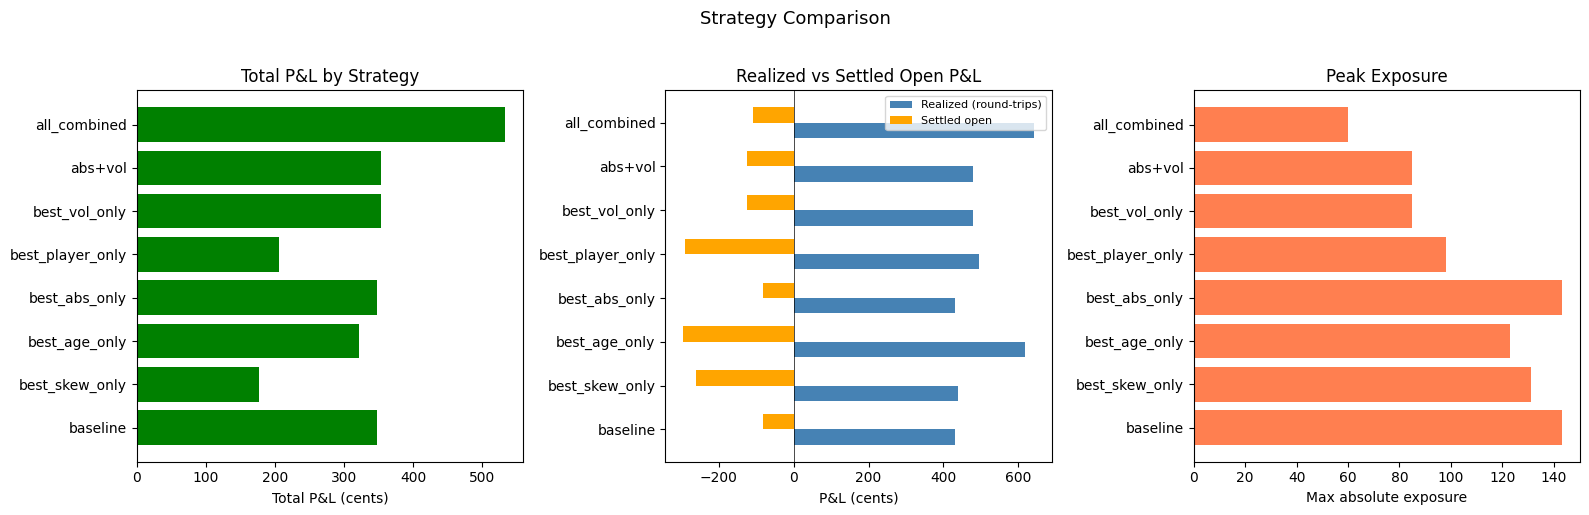

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total P&L comparison
ax = axes[0]
colors = ['red' if r['total_pnl'] < 0 else 'green' for r in combined_results]
ax.barh(range(len(combined_results)), [r['total_pnl'] for r in combined_results], color=colors)
ax.set_yticks(range(len(combined_results)))
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Total P&L (cents)')
ax.set_title('Total P&L by Strategy')
ax.axvline(0, color='black', linewidth=0.5)

# Realized vs settled breakdown
ax = axes[1]
x = range(len(combined_results))
w = 0.35
ax.barh([i - w/2 for i in x], [r['realized_pnl'] for r in combined_results],
        height=w, label='Realized (round-trips)', color='steelblue')
ax.barh([i + w/2 for i in x], [r['settled_pnl'] for r in combined_results],
        height=w, label='Settled open', color='orange')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('P&L (cents)')
ax.set_title('Realized vs Settled Open P&L')
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)

# Max exposure
ax = axes[2]
ax.barh(x, [r['max_abs_exposure'] for r in combined_results], color='coral')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Max absolute exposure')
ax.set_title('Peak Exposure')

plt.suptitle('Strategy Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Exposure over time: baseline vs best

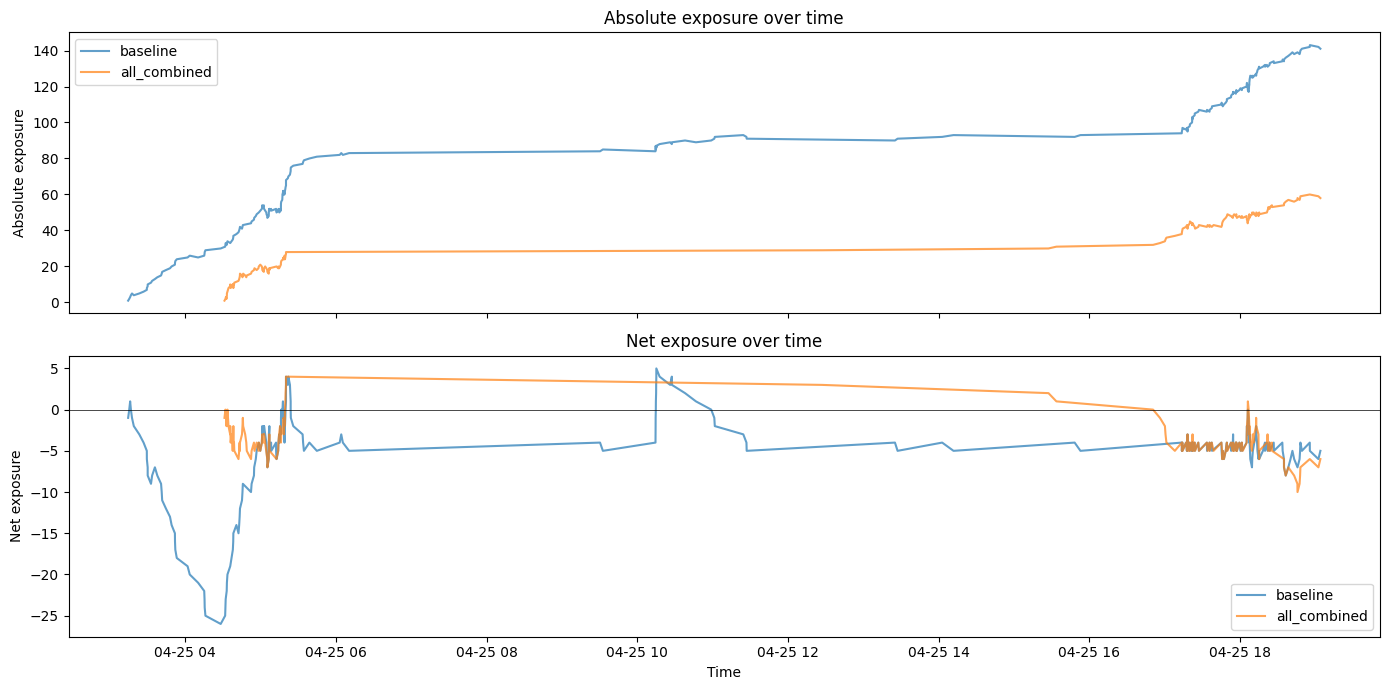

In [35]:
def exposure_timeseries(config: BTConfig, events: list[Event]) -> pd.DataFrame:
    """Replay and record exposure at each fill."""
    strategy = BTStrategy(config)
    client = BTPaperClient(strategy)
    strategy.set_client(client)

    records = []
    for event in events:
        strategy.on_event(event)
        # Check if new fills were added
        while len(records) < len(strategy.fills):
            f = strategy.fills[len(records)]
            abs_exp = sum(abs(v) for v in strategy._positions.values())
            net_exp = sum(strategy._positions.values())
            records.append({
                't': f['t_receipt'],
                'abs_exposure': abs_exp,
                'net_exposure': net_exp,
            })
    return pd.DataFrame(records)

# Find best combined config
best_combined_name = cdf.loc[cdf['total_pnl'].idxmax(), 'name']
best_combined_cfg = dict(combined_configs)[best_combined_name]

ts_baseline = exposure_timeseries(BTConfig(), events)
ts_best = exposure_timeseries(best_combined_cfg, events)

ts_baseline['t_dt'] = pd.to_datetime(ts_baseline['t'], unit='s', utc=True)
ts_best['t_dt'] = pd.to_datetime(ts_best['t'], unit='s', utc=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(ts_baseline['t_dt'], ts_baseline['abs_exposure'], alpha=0.7, label='baseline')
ax.plot(ts_best['t_dt'], ts_best['abs_exposure'], alpha=0.7, label=best_combined_name)
ax.set_ylabel('Absolute exposure')
ax.set_title('Absolute exposure over time')
ax.legend()

ax = axes[1]
ax.plot(ts_baseline['t_dt'], ts_baseline['net_exposure'], alpha=0.7, label='baseline')
ax.plot(ts_best['t_dt'], ts_best['net_exposure'], alpha=0.7, label=best_combined_name)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Net exposure')
ax.set_xlabel('Time')
ax.set_title('Net exposure over time')
ax.legend()

plt.tight_layout()
plt.show()

## 13. Summary & recommended config

In [36]:
print('=' * 70)
print('RECOMMENDED CONFIGURATION')
print('=' * 70)
print()
print(f'Best strategy: {best_combined_name}')
print()
best_r = cdf[cdf['name'] == best_combined_name].iloc[0]
base_r = cdf[cdf['name'] == 'baseline'].iloc[0]
print(f'                      Baseline    Best')
print(f'  Total P&L:       {base_r["total_pnl"]:+8.0f}c  {best_r["total_pnl"]:+8.0f}c')
print(f'  Realized:        {base_r["realized_pnl"]:+8.0f}c  {best_r["realized_pnl"]:+8.0f}c')
print(f'  Settled open:    {base_r["settled_pnl"]:+8.0f}c  {best_r["settled_pnl"]:+8.0f}c')
print(f'  Round-trips:     {base_r["round_trips"]:>8}   {best_r["round_trips"]:>8}')
print(f'  Win rate:        {base_r["win_rate"]:>8.0%}   {best_r["win_rate"]:>8.0%}')
print(f'  Max abs exposure:{base_r["max_abs_exposure"]:>8}   {best_r["max_abs_exposure"]:>8}')
print(f'  Settled W/L:     {base_r["settled_wins"]:.0f}/{base_r["settled_losses"]:.0f}'
      f'       {best_r["settled_wins"]:.0f}/{best_r["settled_losses"]:.0f}')
print()
print('Config params to apply:')
cfg = best_combined_cfg
print(f'  skew_threshold:               {cfg.skew_threshold}')
print(f'  skew_cents_per_contract:       {cfg.skew_cents_per_contract}')
print(f'  age_skew_interval_s:           {cfg.age_skew_interval_s}')
print(f'  age_skew_step_cents:           {cfg.age_skew_step_cents}')
print(f'  max_age_skew_cents:            {cfg.max_age_skew_cents}')
print(f'  abs_exposure_soft_limit:       {cfg.abs_exposure_soft_limit}')
print(f'  use_player_skew:               {cfg.use_player_skew}')
print(f'  player_skew_cents_per_contract: {cfg.player_skew_cents_per_contract}')

RECOMMENDED CONFIGURATION

Best strategy: all_combined

                      Baseline    Best
  Total P&L:           +347c      +533c
  Realized:            +430c      +642c
  Settled open:         -83c      -109c
  Round-trips:           65         64
  Win rate:             72%        72%
  Max abs exposure:     143         60
  Settled W/L:     7/42       4/27

Config params to apply:
  skew_threshold:               3
  skew_cents_per_contract:       1
  age_skew_interval_s:           1800.0
  age_skew_step_cents:           1
  max_age_skew_cents:            10
  abs_exposure_soft_limit:       150
  use_player_skew:               True
  player_skew_cents_per_contract: 2
